# Interpretation Assessment Demo, IMDb Engagement Signals

Purpose: demonstrate how interpretation is assessed quantitatively (not thematically) by fitting a simple regression model and evaluating effect size, statistical significance, and explained variance. The visual deliverable is a coefficient plot with confidence intervals.

In [ ]:
# ------------------------------------------------------------
# NOTEBOOK SETUP
# ------------------------------------------------------------
# This notebook reads from an existing SQLite database (imdb_data.db),
# pulls a modeling dataset with one row per title, then fits a simple
# regression model and generates a visual coefficient plot.
#
# Requirements:
#   pandas, numpy, matplotlib, statsmodels

from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

# Make display a little easier to read in Jupyter.
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DB_PATH = Path("imdb_data.db")

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the database file at: {DB_PATH.resolve()}\n"
        "Update DB_PATH to the correct location of imdb_data.db."
    )

print(f"Using database: {DB_PATH.resolve()}")

Using database: C:\Users\JanMc\Dropbox\Education\_GitHub_coursework\janmcconnellCityU-coursework\DS687_CAPSTONE\imdb_data.db


In [ ]:
# This cell lists tables and views so I can pick the correct source.

with sqlite3.connect(DB_PATH) as conn:
    objects = pd.read_sql_query(
        """
        SELECT name, type
        FROM sqlite_master
        WHERE type IN ('table','view')
        ORDER BY type, name;
        """,
        conn
    )

display(objects)

,name,type
0,actors_pivot,table
1,actresses_pivot,table
2,directors_pivot,table
3,filtered_movies,table
4,name_basics,table
5,title_akas,table
6,title_basics,table
7,title_crew,table
8,title_episode,table
9,title_principals,table


In [4]:
# INSPECT filtered_movies STRUCTURE

with sqlite3.connect(DB_PATH) as conn:
    schema = pd.read_sql_query(
        "PRAGMA table_info(filtered_movies);",
        conn
    )

display(schema)

,cid,name,type,notnull,dflt_value,pk
0,0,tconst,TEXT,0,None,0
1,1,primaryTitle,TEXT,0,None,0
2,2,originalTitle,TEXT,0,None,0
3,3,startYear,REAL,0,None,0
4,4,runtimeMinutes,TEXT,0,None,0
5,5,genres,TEXT,0,None,0
6,6,averageRating,REAL,0,None,0
7,7,numVotes,INT,0,None,0


In [5]:
# PULL MODELING DATA FROM filtered_movies

SQL_MODEL = """
SELECT
    tconst,
    averageRating,
    numVotes,
    startYear,
    genres
FROM filtered_movies
WHERE averageRating IS NOT NULL
  AND numVotes IS NOT NULL
  AND startYear IS NOT NULL
  AND genres IS NOT NULL;
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(SQL_MODEL, conn)

print("Rows:", len(df))
display(df.head())

Rows: 18371


,tconst,averageRating,numVotes,startYear,genres
0,tt0004972,6.1,27935,1915.0,"Drama,War"
1,tt0006206,7.3,5798,1915.0,"Action,Adventure,Crime"
2,tt0006864,7.7,17708,1916.0,"Drama,History"
3,tt0009968,7.2,11651,1919.0,"Drama,Romance"
4,tt0010323,8.0,75092,1920.0,"Horror,Mystery,Thriller"


## Feature preparation

Prepare variables for regression:

- Convert numeric fields to appropriate types
- Create log-transformed vote count
- Extract a primary genre from the comma-separated genres field
- Remove missing or extremely sparse categories

In [6]:
# Ensure numeric types are correct
df["averageRating"] = pd.to_numeric(df["averageRating"], errors="coerce")
df["numVotes"] = pd.to_numeric(df["numVotes"], errors="coerce")
df["startYear"] = pd.to_numeric(df["startYear"], errors="coerce")

# Drop any rows with missing critical values
df = df.dropna(subset=["averageRating", "numVotes", "startYear", "genres"])

# Log transform vote count to reduce right skew
df["log_numVotes"] = np.log1p(df["numVotes"])

# Extract primary genre (first listed genre)
df["primaryGenre"] = (
    df["genres"]
    .astype(str)
    .str.split(",", expand=False)
    .str[0]
    .str.strip()
)

# Remove unknown or empty genres if present
df = df[df["primaryGenre"].notna()]

# Keep genres with sufficient observations for stability
min_count = 300
genre_counts = df["primaryGenre"].value_counts()
valid_genres = genre_counts[genre_counts >= min_count].index
df = df[df["primaryGenre"].isin(valid_genres)].copy()

print("Rows after cleaning:", len(df))
print("Number of genres retained:", df["primaryGenre"].nunique())
df.head()

Rows after cleaning: 17958
Number of genres retained: 8


,tconst,averageRating,numVotes,startYear,genres,log_numVotes,primaryGenre
0,tt0004972,6.1,27935,1915.0,"Drama,War",10.237671,Drama
1,tt0006206,7.3,5798,1915.0,"Action,Adventure,Crime",8.665441,Action
2,tt0006864,7.7,17708,1916.0,"Drama,History",9.781828,Drama
3,tt0009968,7.2,11651,1919.0,"Drama,Romance",9.363233,Drama
4,tt0010323,8.0,75092,1920.0,"Horror,Mystery,Thriller",11.226483,Horror


## Regression model

Model specification:

log(numVotes) ~ primaryGenre + startYear

Interpretation will be assessed using:
- Coefficient magnitude and direction
- Statistical significance (p-values)
- R-squared and adjusted R-squared

In [7]:
model = smf.ols(
    formula="log_numVotes ~ C(primaryGenre) + startYear",
    data=df
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           log_numVotes   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     93.24
Date:                Tue, 17 Feb 2026   Prob (F-statistic):          1.54e-152
Time:                        16:42:24   Log-Likelihood:                -29062.
No. Observations:               17958   AIC:                         5.814e+04
Df Residuals:                   17949   BIC:                         5.821e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.5423      0.915      0.593      0.553      -1.251       2.336
C(primaryGenre)[T.Adventure]       0.1274      0.039      3.271      0.001       0.051       0.204
C(primaryGenre)[T.Biography]      -0.2254      0.042     -5.353      0.000      -0.308      -0.143
C(primaryGenre)[T.Comedy]         -0.4041      0.026    -15.421      0.000      -0.455      -0.353
C(primaryGenre)[T.Crime]          -0.2951      0.036     -8.102      0.000      -0.366      -0.224
C(primaryGenre)[T.Documentary]    -1.0196      0.072    -14.245      0.000      -1.160      -0.879
C(primaryGenre)[T.Drama]          -0.4450      0.027    -16.259      0.000      -0.499      -0.391
C(primaryGenre)[T.Horror]         -0.3129      0.043     -7.235      0.000      -0.398      -0.228
startYear                          0.0049      0.000     10.680      0.000       0.004       0.006
==============================================================================
Omnibus:                     1728.383   Durbin-Watson:                   1.854
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2275.986
Skew:                           0.868   Prob(JB):                         0.00
Kurtosis:                       3.168   Cond. No.                     2.01e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.01e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

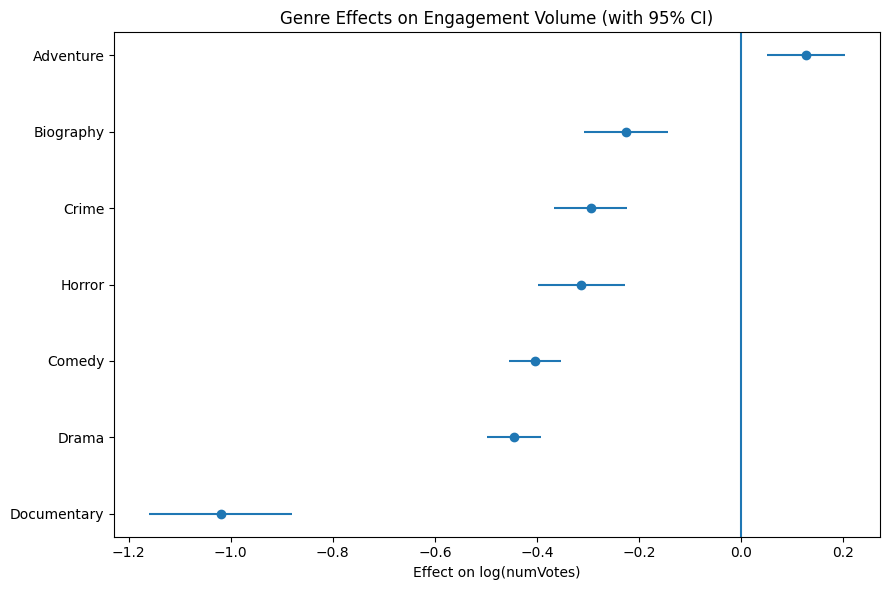

In [11]:
coef_df = model.params.to_frame("coef")
conf_df = model.conf_int()
conf_df.columns = ["ci_low", "ci_high"]

coef_df = coef_df.join(conf_df)

genre_mask = coef_df.index.str.startswith("C(primaryGenre)")
genre_coefs = coef_df[genre_mask].copy()

genre_coefs["genre"] = (
    genre_coefs.index
    .str.replace("C(primaryGenre)[T.", "", regex=False)
    .str.replace("]", "", regex=False)
)

genre_coefs = genre_coefs.sort_values("coef")

plt.figure(figsize=(9,6))
y = np.arange(len(genre_coefs))

plt.hlines(y, genre_coefs["ci_low"], genre_coefs["ci_high"])
plt.plot(genre_coefs["coef"], y, "o")

plt.yticks(y, genre_coefs["genre"])
plt.axvline(0)
plt.xlabel("Effect on log(numVotes)")
plt.title("Genre Effects on Engagement Volume (with 95% CI)")
plt.tight_layout()
plt.show()

In [12]:
# The baseline category is the genre that does NOT appear in the coefficient list.
# Statsmodels omits it and encodes others relative to it.

all_genres = sorted(df["primaryGenre"].unique())
estimated_genres = [
    idx.replace("C(primaryGenre)[T.", "").replace("]", "")
    for idx in model.params.index
    if idx.startswith("C(primaryGenre)")
]

baseline = list(set(all_genres) - set(estimated_genres))

print("All genres in model:", all_genres)
print("Estimated genres:", sorted(estimated_genres))
print("Baseline genre (reference category):", baseline)

All genres in model: ['Action', 'Adventure', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Horror']
Estimated genres: ['Adventure', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Horror']
Baseline genre (reference category): ['Action']
